## Figures 4d, 4e, 4f — QHO wavefunctions and Bloch wave profiles

This notebook reproduces **Figures 4d, 4e, and 4f** of the paper.

In the QHO narrow-pass-band limit, the Bloch wave envelope for mode $n$ is
proportional to the $n$-th Hermite–Gaussian eigenfunction of a quantum harmonic oscillator.
This notebook verifies that equivalence by overlaying time-domain Bloch wave solutions
on the Transmon eigenstates for modes $n = 0, 1, 2, 3$.


In [1]:
import numpy as np
import itertools
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [2]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [3]:
def compute_energy(fft_wave, k,NN):
    eps0 = 8.854e-12
    # Compute the squared amplitude of the FFT (energy density in Fourier space)
    amplitude_squared = np.abs(fft_wave)**2
    
    # Compute the spacing in k-space (assumes uniform sampling in k)
    dk = np.abs(k[1] - k[0])  # Assumes k is sorted and evenly spaced
    
    # Integrate energy density over all wavenumbers
    total_energy = eps0*np.sum(amplitude_squared) * (dk)
    
    return total_energy

In [4]:
def compute_floquet_multipliers(AA, qtest):
    
    y_1 = [1., 0.0]
    y_2 = [0.0, 1.]
   
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    # Assembly of the monodromy matrix Phi
    mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , 
                         [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
    eigenValues, _ = scipy.linalg.eig(mat_phi)
    rho1      = eigenValues[0]
    rho2       = eigenValues[1]
    #print(rho1,rho2)
    # Replace log(0) issue with large negative value (-∞)
    solouf = np.array([
        cm.log(ev) / np.pi if not np.isclose(ev, 0) else -np.inf
        for ev in eigenValues
    ], dtype=complex)
    solfinal = solouf[np.argsort(solouf.real)] 
            
    return solfinal


In [5]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]



In [6]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

### → Figure 4d — QHO bound states

Diagonalizes the Transmon Hamiltonian at $q = E_J/(8E_C) = 20$ and overlays
the eigenstates with the analytic Hermite-polynomial approximation.
Produces `QHO_bound_states.png`.


[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_73416/3862909613.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_73416/3862909613.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors2[inc,:] = p_monic(chi2)*np.exp(-np.sqrt(qtest)*(phi2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))


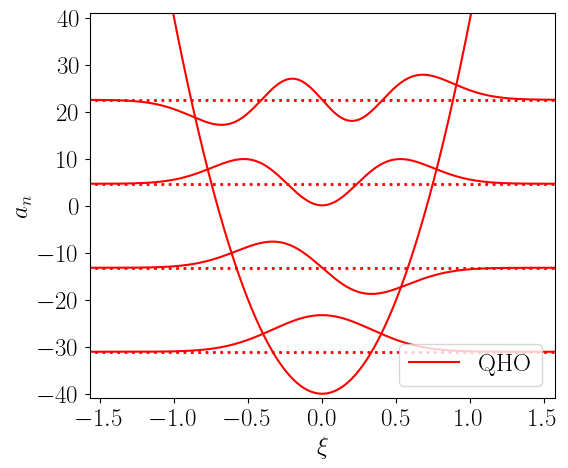

In [7]:
qtest = 20
phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)
phi2 = np.linspace(-phi_max/2, phi_max/2, num_points)

#Laplacy = calculate_laplace_three_point(phi)
#Potent = diags(qtest*phi**2)
#energies, states = eigs((-Laplacy+Potent),k=4, which='SR')

E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenval, eigenvec = eigh(H.toarray())
eigenval = eigenval[:5]  # Only take the first 10 eigenvalues
eigenvec = eigenvec[:, :5]
print(eigenval)

nlist = np.linspace(0,3,4)
energiesana = (0.5+nlist)*4*np.sqrt(qtest)
eigenvectors = np.zeros((nlist.size,phi.size))
eigenvectors2 = np.zeros((nlist.size,phi2.size))

chi = np.sqrt(2)*(qtest)**0.25*(phi/2)
chi2 = np.sqrt(2)*(qtest)**0.25*(phi2)
inc = -1
for nn in nlist:
    inc = inc + 1
    p_monic = sp.hermite(nn.astype(int), monic=True)
    eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))
    eigenvectors2[inc,:] = p_monic(chi2)*np.exp(-np.sqrt(qtest)*(phi2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))
    
    
Amp0 = 6
Amp1 = 10
Amp2 = 20
Amp3 = 42

fonty = 18
fig7 = plt.figure(7, figsize=(6, 5))
plt.rc('text', usetex=True)

#plt.plot(phi/2, eigenvec[:, 0]*148 + eigenval[0]+0.25,'g-')
#plt.plot(phi/2, eigenvec[:, 1]*104 + eigenval[1]+1.25,'g-')

#plt.plot(xxquantum, energiesana[0]+Amp*states[:, 0].real, label='$\psi_0$')
plt.plot(phi/2, -2*qtest+energiesana[0]+Amp0*eigenvectors[0,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[1]-Amp1*eigenvectors[1,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[2]+Amp2*eigenvectors[2,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[3]+Amp3*eigenvectors[3,:].real,'r-')
#plt.plot(phi2, -2*qtest+energiesana[0]+Amp0*eigenvectors2[0,:].real,'g-')

plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[0]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[1]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[2]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[3]),'r:',linewidth=2)

plt.plot(phi/2, 4*qtest*(phi/2)**2-2*qtest,'r-',markersize=3.,label=r'$\mathrm{QHO}$')
#plt.plot(phi/2, -2*qtest * np.cos(phi),'g-',linewidth=2)

plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
legend = plt.legend(fontsize=fonty,loc='lower right')
plt.xlim(-phi_max/2, phi_max/2)
#plt.ylim(-1-2*qtest, 4*qtest*(np.pi/2)**2-2*qtest)
plt.ylim(-1-2*qtest, 40+1)
fig7 = plt.gcf()
plt.show()

fig7.savefig('QHO_bound_states.png', format='png', dpi=1000,bbox_inches='tight')


In [8]:
def equation_lin_HQO(t, y, ala, qlq):  
    qq, pp  = y
    dydt = [pp, -(ala+2*qlq-4*qlq*(t-np.pi/2)**2)*qq]
    return dydt


def equation_lin_HQO_time(t, y, xi, epsofxi):
    epsxi = np.interp(t, xi, epsofxi)   
    qq, pp  = y
    dydt = [pp, -1*epsxi*qq]
    return dydt

# Define the base function over [0, pi]
def f_base(x, ala, qlq):
    return (ala+2*qlq-4*qlq*(x-np.pi/2)**2)

def f_base_physical(x, alph2, bet2, lamb):
    eps0 = 8.854e-12
    return -alph2*eps0+bet2*eps0*(1-(2*np.pi/lamb)**2*(x-lamb/2)**2/2)



In [9]:
def sol_comp_mode_floquet(t, y, ala, qlq, sn):
    JJ = np.array([ [0.,1 ],
                       [-(ala+2*qlq-4*qlq*(t-np.pi/2)**2),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



### QHO $F(x)$ profile (dimensionless units)

Plots the piecewise-parabolic $F(x)$ in the reduced $(a, q)$ parameterization
for a visual check of the operating point.


-31.05572809000084 20


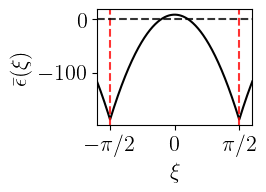

In [10]:
#ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
ymax = 6e16
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 1*100e-9
kmax = 2e8
vv = 299792458
#vv = vv + 15700000
atest = -2*qtest+energiesana[0]
qtest = 20
print(atest,qtest)

xplot = np.array(np.linspace(-2*np.pi,2*np.pi,2000))
yplot = f_base(xplot %np.pi,atest,qtest)


fonty = 16
fig1 = plt.figure(1, figsize=(2, 1.5))
plt.rc('text', usetex=True)

plt.plot(xplot-np.pi/2,yplot,'k-')
plt.axvline(x=-np.pi/2, color='r', linestyle='--', alpha=0.8)
plt.axvline(x=np.pi/2, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\xi$',fontsize=fonty)
plt.ylabel(r'$\bar{\epsilon}(\xi)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(-np.pi/2-np.pi/2/5, np.pi/2+np.pi/2/5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(-0.4e-9, 2e-11)   # set the ylim to ymin, ymax
#plt.grid()
plt.xticks([-np.pi/2, 0, np.pi/2], [r'$-\pi/2$', r'$0$', r'$\pi/2$'], fontsize=fonty)
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

#fig1.savefig('Modulation_negative_HQO_dimless.png', format='png', dpi=1000, bbox_inches='tight')


### Floquet data for QHO pass bands

Integrates the QHO Mathieu ODE along the dispersion locus to build
the Floquet multiplier arrays used in the wavefunction comparison plots.


In [ ]:

epsi = 1e-2
ncoarse = int(500)
nacc = int(50000)
aa1 = np.linspace(-40, -2*qtest+energiesana[0]-epsi, ncoarse)
aa2 = np.linspace(aa1[-1], -2*qtest+energiesana[0], nacc)
aa3 = np.linspace(aa2[-1], -2*qtest+energiesana[1]-epsi, ncoarse)
aa4 = np.linspace(aa3[-1], -2*qtest+energiesana[1], nacc)
aa5 = np.linspace(aa4[-1], -2*qtest+energiesana[2]-epsi, ncoarse)
aa6 = np.linspace(aa5[-1], -2*qtest+energiesana[2], nacc)
aa7 = np.linspace(aa6[-1], -2*qtest+energiesana[3]-2*epsi, ncoarse)
aa8 = np.linspace(aa7[-1], -2*qtest+energiesana[3], nacc)
aa9 = np.linspace(aa8[-1], 25, ncoarse)
# Combine all regions

listA = np.concatenate([aa1,aa2,aa3,aa4,aa5,aa6,aa7,aa8,aa9])
print(listA.size)
#listA = np.linspace(-40,25,3000)
listabsrho1 = np.ones(listA.size)
listabsrho2 = np.ones(listA.size)

y_1 = [1., 0.0]
y_2 = [0.0, 1.]
inc = -1
for AA in listA:
    inc = inc + 1
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                    t_eval=None,args=(AA, qtest))
    # Assembly of the monodromy matrix Phi
    mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , 
                         [ sol1.y[1,-1], sol2.y[1,-1] ] ])
    eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
    listabsrho1[inc]       = np.abs(eigenValues[0])
    listabsrho2[inc]       = np.abs(eigenValues[1])
    
#print(listabsrho1)
#print(listabsrho2)
with open('Test.npy', 'wb') as f:
    np.save(f, listA)
    np.save(f, listabsrho1)
    np.save(f, listabsrho2)


### Load `Test.npy` — Floquet multipliers vs frequency

Loads precomputed Floquet data and plots $|\rho|$ vs $a$
to identify the pass-band frequencies for modes 0–3.


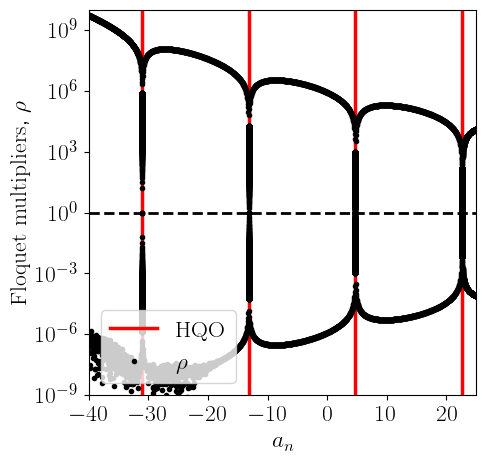

In [11]:
with open('Test.npy', 'rb') as f:
    listA = np.load(f)
    listabsrho1 = np.load(f)
    listabsrho2 = np.load(f)

fonty = 17
fig3 = plt.figure(3, figsize=(5, 5))
plt.rc('text', usetex=True)

plt.plot([-2*qtest+energiesana[0], -2*qtest+energiesana[0]],[1e-9, 1e10],'r-',linewidth=2.5, label=r'$\mathrm{HQO}$')
plt.plot([-2*qtest+energiesana[1], -2*qtest+energiesana[1]],[1e-9, 1e10],'r-',linewidth=2.5)
plt.plot([-2*qtest+energiesana[2], -2*qtest+energiesana[2]],[1e-9, 1e10],'r-',linewidth=2.5)
plt.plot([-2*qtest+energiesana[3], -2*qtest+energiesana[3]],[1e-9, 1e10],'r-',linewidth=2.5)

plt.plot(listA, listabsrho1, 'k.',label=r'$\rho$',linewidth=2.)
plt.plot(listA, listabsrho2, 'k.',linewidth=2.)
plt.plot([np.min(listA),np.max(listA)],[1.,1.],'k--',linewidth=2.)
legend = plt.legend(fontsize=fonty,loc='lower left')
plt.xlabel(r'$a_n$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Floquet}$ $\mathrm{multipliers}$, $\rho$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(xliminf-TT/2., xlimsup-TT/2.)   # set the ylim to ymin, ymax
plt.xlim(np.min(listA),np.max(listA))   # set the ylim to ymin, ymax
plt.ylim(1e-9, 1e10)   # set the ylim to ymin, yma
plt.yscale('log')
fig3 = plt.gcf()
plt.show()

#fig3.savefig('Floquet_HQO.png', format='png', dpi=1000,bbox_inches='tight')

### → Figure 4e — Bloch wave mode $n = 0$

Integrates the QHO Mathieu ODE at the mode-0 pass-band frequency and plots
the Bloch wave envelope overlaid on the QHO ground-state eigenfunction.
Produces `Mathieu_mode0_QHO.png`.


(-0.02440404708844157+0.9997021765366216j) (-0.024404047088441655-0.9997021765366216j)
0.9999999996431767 0.9999999996431767
[-2.83369167e-17+1.37472158j  2.83369167e-17-1.37472158j]


/Users/Arnaud/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


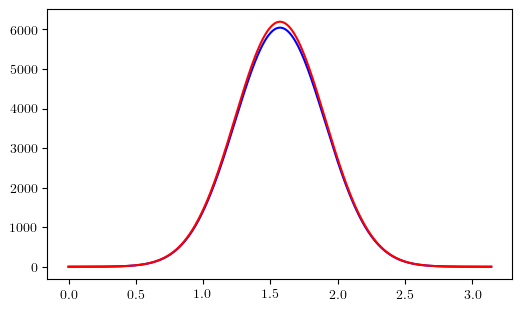

0.9758865948200782
(-0.02440404708844157+0.9997021765366216j) (-0.024404047088441655-0.9997021765366216j)
0.9999999996431767 0.9999999996431767
[-2.83369167e-17+1.37472158j  2.83369167e-17-1.37472158j]


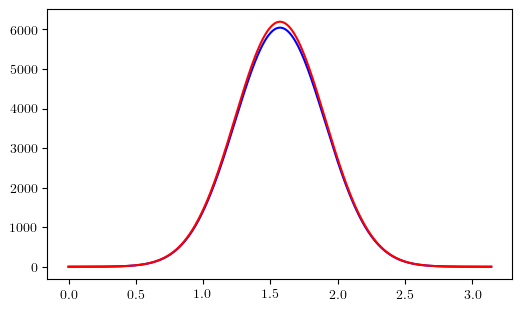

0.9758865948200782


In [12]:
indices = np.where(np.isclose(listabsrho2, 1.))[0]
lamb = 100e-9
kmax = 2e8 
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
###########################################################################
atest0 = listA[indices[0]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+(1/0.97588659)*1j)*eigenvectors[0,:]*rho1**ii #We can try some complex constant

    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended0 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic0 = f_base(x_extended0 % np.pi,atest0,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended0,args=(x_extended0, y_periodic0))
#q0 = solist.y[0,:]
#qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended0*lamb/np.pi)
wave = np.real(qlist0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim0 = np.real(qlist0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq0A = MAtFloq
rho0A = rho1
coeff0A = (1+(1/0.97588659)*1j)




###########################################################################
atest1 = listA[indices[1]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+(1/0.975886594820078)*1j)*eigenvectors[0,:]*rho1**ii #We can try some complex constant

qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended1 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic1 = f_base(x_extended1 % np.pi,atest1,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended1,args=(x_extended1, y_periodic1))
#q1 = solist.y[0,:]
#qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended1*lamb/np.pi)
wave1 = np.real(qlist1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k1, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(qlist1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)

MAtFloq0B = MAtFloq
rho0B = rho1
coeff0B = (1+(1/0.975886594820078)*1j)


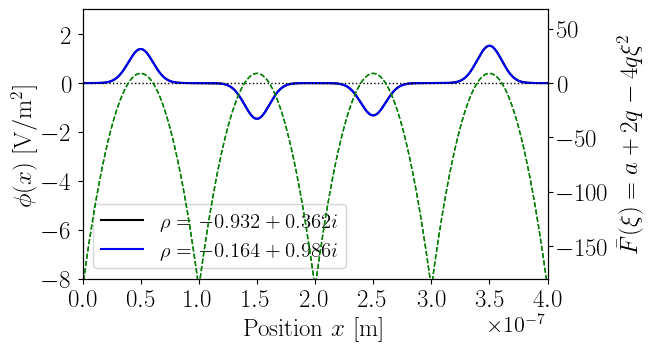

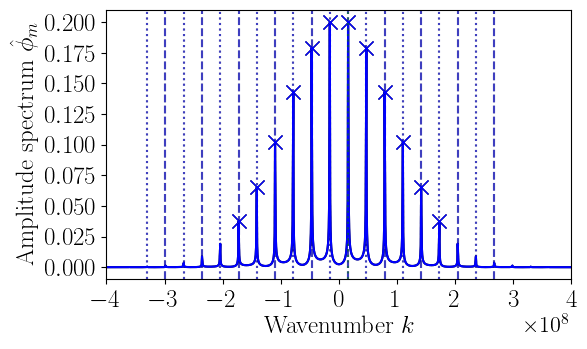

In [ ]:
ampi = 0.2
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()    


#ax1.plot(x_extended0*lamb/np.pi,qlist0*0.0003,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,qopti0*1.4,'r-',linewidth=1.5,label=r'Opti')
#ax1.plot(x_extended0*lamb/np.pi,qlist1*0.003,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,-qopti1*4.2,'r-',linewidth=1.5,label=r'Opti')

ax1.plot(x_extended0*lamb/np.pi,q0adim0*ampi,'k-',linewidth=1.5,label=r'$\rho=-0.932+0.362i$')
ax1.plot(x_extended1*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.164+0.986i$')


ax2.plot(x_extended0*lamb/np.pi, y_periodic0, 'g--',linewidth=1.)
ax2.plot(x_extended1*lamb/np.pi, y_periodic1, 'g--',linewidth=1.)
ax1.plot(np.array([x_extended0[0],x_extended0[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 3.02)
ax2.set_ylim(-180, 68)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$ $\mathrm{[V/m^2]}$',fontsize=fonty)
ax2.set_ylabel(r'$\bar{F}(\xi)=a+2q-4q\xi^2$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower left')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_QHO.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5) 

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim*ampi,'k')
plt.plot(k1, fftadim1*ampi,'b')
plt.plot(peak_waveadim0, peak_ampadim0*ampi,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1*ampi,'xb',markersize=10)
plt.axvline(x=np.imag(ff1)*np.pi/lamb, color='g', linestyle=':', alpha=0.5) 

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### → Figure 4e — Bloch wave mode $n = 1$

Same as above for mode 1. Produces `Mathieu_mode1_QHO.png`.


(-0.932200133661104+0.36194325334905203j) (-0.9322001336611038-0.361943253349052j)
1.0000000039213381 1.000000003921338
[-6.44498332e-17-0.25757384j  6.44498332e-17+0.25757384j]


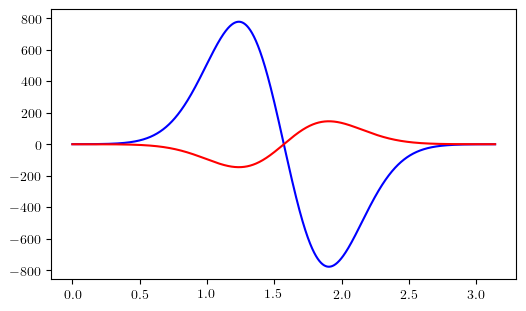

5.338405866591117
(-0.163706120217756+0.9865091537651544j) (-0.1637061202177559-0.9865091537651545j)
1.0000000021295956 1.0000000021295956
[-2.13685126e-17-1.07886727j  2.13685126e-17+1.07886727j]


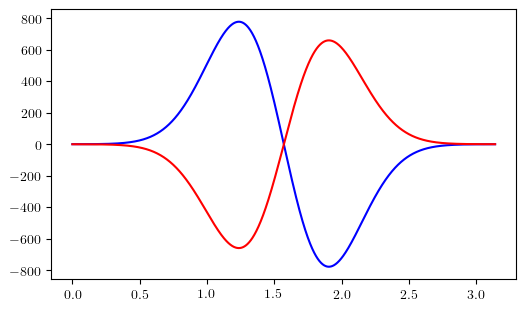

1.1796201898797585


In [14]:
indices = np.where(np.isclose(listabsrho2, 1.))[0]
lamb = 100e-9
kmax = 2e8 
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = listA[indices[2]]

sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-(1/5.3384)*1j)*eigenvectors[1,:]*rho1**ii #We can try some complex constant

    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))
qopti0 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended0 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic0 = f_base(x_extended0 % np.pi,atest0,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended0,args=(x_extended0, y_periodic0))
#q0 = solist.y[0,:]
#qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended0*lamb/np.pi)
wave = np.real(qlist0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim0 = np.real(qlist0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq1A = MAtFloq
rho1A = rho1
coeff1A = (1-(1/5.3384)*1j)




###########################################################################
atest1 = listA[indices[6]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-(1/1.17962)*1j)*eigenvectors[1,:]*rho1**ii #We can try some complex constant

qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended1 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic1 = f_base(x_extended1 % np.pi,atest1,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended1,args=(x_extended1, y_periodic1))
#q1 = solist.y[0,:]
#qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended1*lamb/np.pi)
wave1 = np.real(qlist1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k1, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(qlist1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)

MAtFloq1B = MAtFloq
rho1B = rho1
coeff1B = (1-(1/1.17962)*1j)


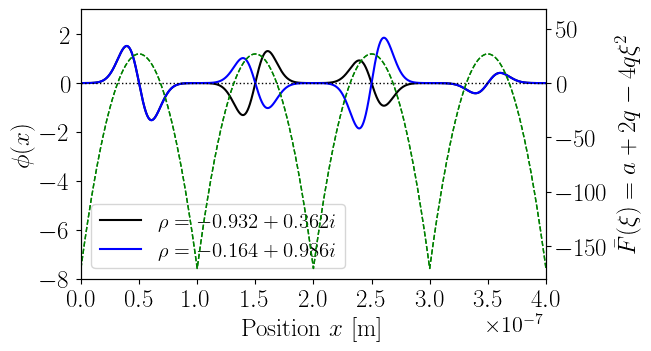

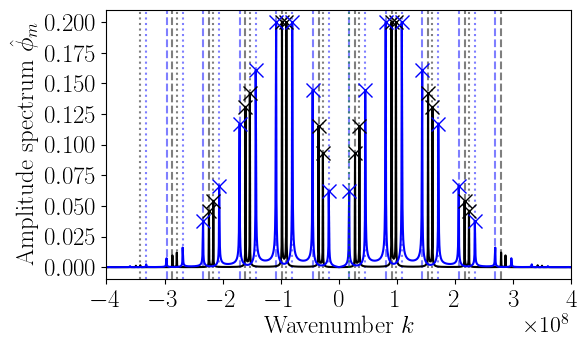

In [15]:
ampi = 0.2
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()    


#ax1.plot(x_extended0*lamb/np.pi,qlist0*0.003,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,-qopti0*4.2,'r-',linewidth=1.5,label=r'Opti')
#ax1.plot(x_extended0*lamb/np.pi,qlist1*0.003,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,-qopti1*4.2,'r-',linewidth=1.5,label=r'Opti')

ax1.plot(x_extended0*lamb/np.pi,q0adim0*ampi,'k-',linewidth=1.5,label=r'$\rho=-0.932+0.362i$')
ax1.plot(x_extended1*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=-0.164+0.986i$')


ax2.plot(x_extended0*lamb/np.pi, y_periodic0, 'g--',linewidth=1.)
ax2.plot(x_extended1*lamb/np.pi, y_periodic1, 'g--',linewidth=1.)
ax1.plot(np.array([x_extended0[0],x_extended0[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 3.02)
ax2.set_ylim(-180, 68)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$',fontsize=fonty)
ax2.set_ylabel(r'$\bar{F}(\xi)=a+2q-4q\xi^2$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower left')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode1_QHO.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5) 

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim*ampi,'k')
plt.plot(k1, fftadim1*ampi,'b')
plt.plot(peak_waveadim0, peak_ampadim0*ampi,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1*ampi,'xb',markersize=10)
plt.axvline(x=np.imag(ff1)*np.pi/lamb, color='g', linestyle=':', alpha=0.5) 

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### → Figure 4f — Bloch wave mode $n = 2$

Same as above for mode 2. Produces `Mathieu_mode2_HQO.png`.


(0.5990372895096955+0.8007211282676363j) (0.5990372895096954-0.8007211282676363j)
0.9999999997386596 0.9999999997386595


/Users/Arnaud/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[-6.78126422e-18+0.60500146j  6.78126422e-18-0.60500146j]


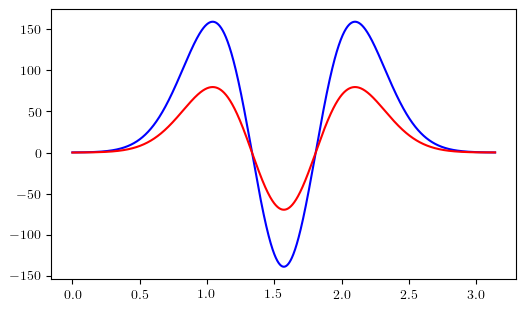

1.9969958850224023
(0.11968838830755812+0.9928115070540128j) (0.11968838830755818-0.9928115070540131j)
0.9999999994172605 0.9999999994172608
[ 3.43952436e-17+1.06126744j -3.43952436e-17-1.06126744j]


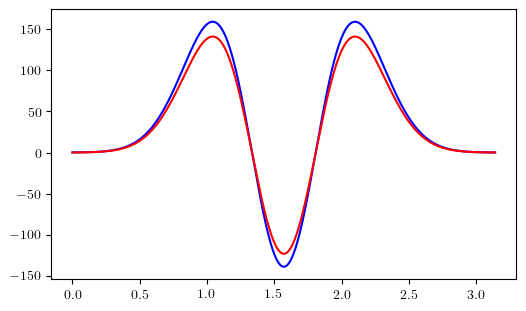

1.1277954693956393


In [16]:
indices = np.where(np.isclose(listabsrho2, 1.))[0]
lamb = 100e-9
kmax = 2e8 
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = listA[indices[50]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+(1/1.9969958850224057)*1j)*eigenvectors[2,:]*rho1**ii #We can try some complex constant

    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))
qopti0 = OptiFloq.reshape((int(nT*nprimary),))


# Generate x values over multiple periods
x_extended0 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic0 = f_base(x_extended0 % np.pi,atest0,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended0,args=(x_extended0, y_periodic0))
#q0 = solist.y[0,:]
#qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended0*lamb/np.pi)
wave = np.real(qlist0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim0 = np.real(qlist0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq2A = MAtFloq
rho2A = rho1
coeff2A = (1+(1/1.9969958850224057)*1j)



###########################################################################
atest1 = listA[indices[100]]



sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1+(1/1.1277954693956393)*1j)*eigenvectors[2,:]*rho1**ii #We can try some complex constant


qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended1 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic1 = f_base(x_extended1 % np.pi,atest1,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended1,args=(x_extended1, y_periodic1))
#q1 = solist.y[0,:]
#qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended1*lamb/np.pi)
wave1 = np.real(qlist1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(qlist1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq2B = MAtFloq
rho2B = rho1
coeff2B = (1+(1/1.1277954693956393)*1j)

/Users/Arnaud/anaconda3/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


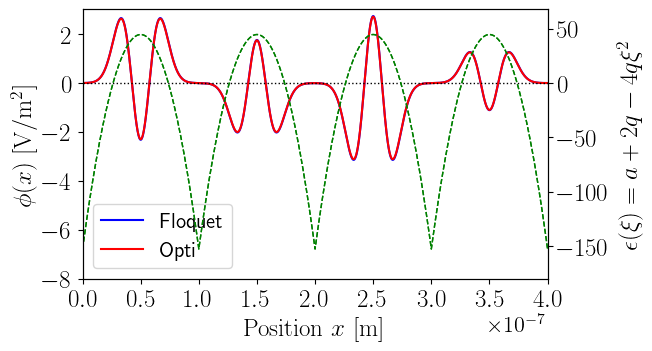

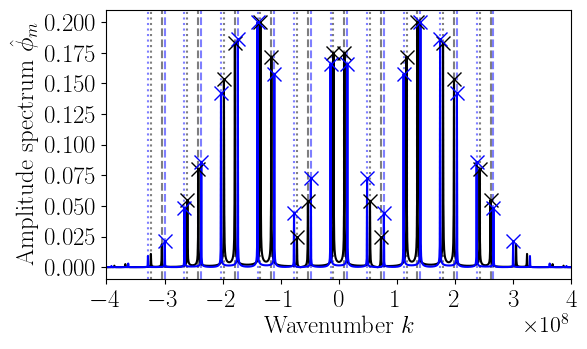

In [17]:
ampi = 0.2
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()    

#ax1.plot(x_extended0*lamb/np.pi,qlist0*0.0167,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,qopti0*10,'r-',linewidth=1.5,label=r'Opti')
ax1.plot(x_extended0*lamb/np.pi,qlist1*0.0167,'b-',linewidth=1.5,label=r'Floquet')
ax1.plot(x_extended0*lamb/np.pi,qopti1*10,'r-',linewidth=1.5,label=r'Opti')

#ax1.plot(x_extended0*lamb/np.pi,q0adim0*ampi,'k-',linewidth=1.5,label=r'$\rho=0.599+0.801i$')
#ax1.plot(x_extended1*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=0.120+0.993i$')


ax2.plot(x_extended0*lamb/np.pi, y_periodic0, 'g--',linewidth=1.)
ax2.plot(x_extended1*lamb/np.pi, y_periodic1, 'g--',linewidth=1.)
ax1.plot(np.array([x_extended0[0],x_extended0[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 3.02)
ax2.set_ylim(-180, 68)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$ $\mathrm{[V/m^2]}$',fontsize=fonty)
ax2.set_ylabel(r'$\epsilon(\xi)=a+2q-4q\xi^2$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower left')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode2_HQO.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5) 

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim*ampi,'k')
plt.plot(k1, fftadim1*ampi,'b')
plt.plot(peak_waveadim0, peak_ampadim0*ampi,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1*ampi,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### → Figure 4f — Bloch wave mode $n = 3$

Same as above for mode 3. Produces `Mathieu_mode3_HQO.png`.


(-0.5622000630486383+0.8270012630568457j) (-0.5622000630486385-0.8270012630568456j)
0.9999999999947555 0.9999999999947555
[ 8.64704303e-18-0.59600052j -8.64704303e-18+0.59600052j]


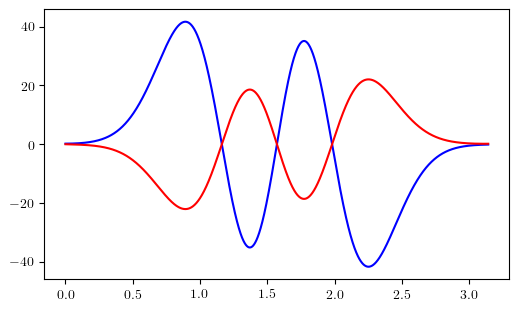

1.8889863999655523
(0.04096304918693483+0.9991606620522263j) (0.040963049186934664-0.9991606620522262j)
0.9999999999956671 0.999999999995667
[ 7.45833902e-17-1.16063064j -7.45833902e-17+1.16063064j]


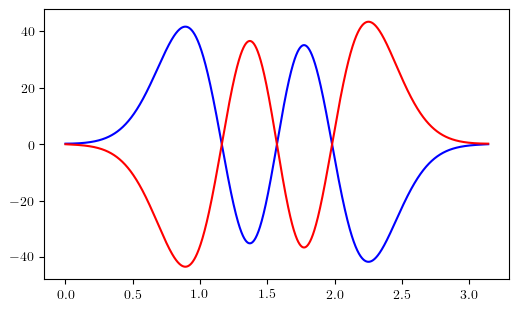

0.9598428483579567


In [18]:
indices = np.where(np.isclose(listabsrho2, 1.))[0]
lamb = 100e-9
kmax = 2e8 
nT = int(100)
nTvisu = 4
y0 = np.array([0.2,0.])

nprimary = 2000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest0 = listA[indices[-400]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest0, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))   

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest0, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-(1/1.8889868)*1j)*eigenvectors[3,:]*rho1**ii #We can try some complex constant

    
qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))
qopti0 = OptiFloq.reshape((int(nT*nprimary),))


# Generate x values over multiple periods
x_extended0 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic0 = f_base(x_extended0 % np.pi,atest0,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended0,args=(x_extended0, y_periodic0))
#q0 = solist.y[0,:]
#qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended0*lamb/np.pi)
wave = np.real(qlist0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim0 = np.real(qlist0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

#indou = np.argmax(peak_amplitudes)
#kfund = peak_wavenumbers[indou]

MAtFloq3A = MAtFloq
rho3A = rho1
coeff3A = (1-(1/1.8889868)*1j)



###########################################################################
atest1 = listA[indices[-1]]


sol1 = solve_ivp(equation_lin_HQO, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
sol2 = solve_ivp(equation_lin_HQO, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest1, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValfloq, eigenVecfloq = scipy.linalg.eig(mat_phi)
rho1 = eigenValfloq[0]
rho2 = eigenValfloq[1]
eigVector1 = eigenVecfloq[:,0]
eigVector2 = eigenVecfloq[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(rho1,rho2)
print(np.abs(rho1),np.abs(rho2))    


#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest1, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVecfloq),y0)
print(cci)

fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)
plt.plot(listcell[0:-1:1],np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'b-')
plt.plot(listcell[0:-1:1],np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))),'r-')
plt.show()
print(np.max(np.abs(np.real(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1])))))/np.max(np.abs(np.imag(2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))))))


MAtFloq = np.zeros((nT,nprimary),dtype=complex)
OptiFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    #OptiFloq[ii,:] = 2*cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]))*rho1**ii #General formula in the case of any initial conditions 
    OptiFloq[ii,:] = (1-(1/0.9598428)*1j)*eigenvectors[3,:]*rho1**ii #We can try some complex constant


qlist1 = MAtFloq.reshape((int(nT*nprimary),))
qplist1 = MAtFloqp.reshape((int(nT*nprimary),))
qopti1 = OptiFloq.reshape((int(nT*nprimary),))

# Generate x values over multiple periods
x_extended1 = np.linspace(0.,np.pi*nT-dt,nT*nprimary)  # Extended domain
# Make it periodic by applying modulo operation
y_periodic1 = f_base(x_extended1 % np.pi,atest1,qtest)
#solist = solve_ivp(equation_lin_HQO_time, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
#                t_eval=x_extended1,args=(x_extended1, y_periodic1))
#q1 = solist.y[0,:]
#qp1 = solist.y[1,:]


# Compute the FFT
L = np.max(x_extended1*lamb/np.pi)
wave1 = np.real(qlist1)
# Length of the wave
N_wave = len(wave1)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave1 = np.fft.fft(wave1)
fft_wave1 = fft_wave1 / N  # Normalize the amplitude
# Compute the wavenumbers
k1 = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k1 = np.fft.fftshift(k1)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted1 = np.fft.fftshift(fft_wave1)

# Find peaks
peak_wavenumbers1, peak_amplitudes1 = find_fft_peaks(fft_wave_shifted1, k, height=0.5, distance=1)
#print(peak_amplitudes)
fftadim1 =  np.abs(fft_wave_shifted1)/np.max(peak_amplitudes1)
q0adim1 = np.real(qlist1)/np.max(peak_amplitudes1)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim1, k1, height=0.1, distance=1)


MAtFloq3B = MAtFloq
rho3B = rho1
coeff3B = (1-(1/0.9598428)*1j)

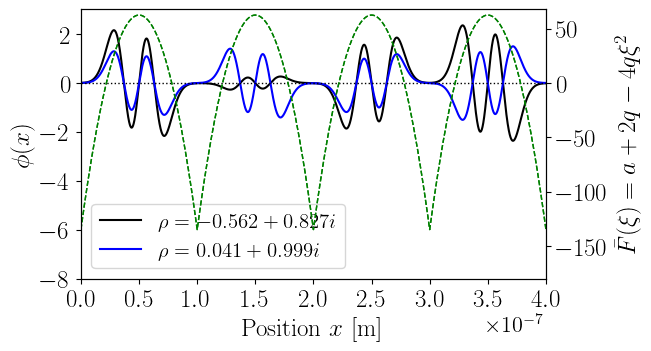

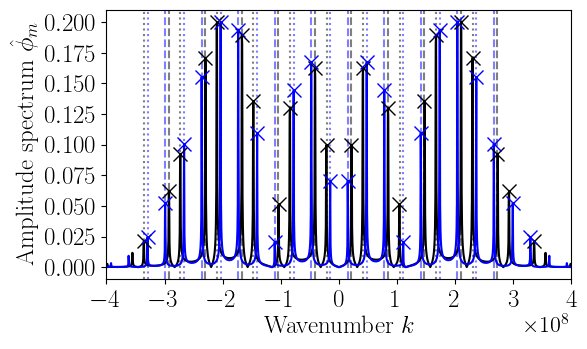

In [19]:
ampi = 0.2
fonty = 18
fig5, ax1 = plt.subplots(1, figsize=(6, 3.5))
plt.rc('text', usetex=True)

ax2 = ax1.twinx()    

#ax1.plot(x_extended0*lamb/np.pi,qlist0*0.06,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,-qopti0*20,'r-',linewidth=1.5,label=r'Opti')
#ax1.plot(x_extended0*lamb/np.pi,qlist1*0.06,'b-',linewidth=1.5,label=r'Floquet')
#ax1.plot(x_extended0*lamb/np.pi,-qopti1*20,'r-',linewidth=1.5,label=r'Opti')

ax1.plot(x_extended0*lamb/np.pi,q0adim0*ampi,'k-',linewidth=1.5,label=r'$\rho=-0.562+0.827i$')
ax1.plot(x_extended1*lamb/np.pi,q0adim1*ampi,'b-',linewidth=1.5,label=r'$\rho=0.041+0.999i$')


ax2.plot(x_extended0*lamb/np.pi, y_periodic0, 'g--',linewidth=1.)
ax2.plot(x_extended1*lamb/np.pi, y_periodic1, 'g--',linewidth=1.)
ax1.plot(np.array([x_extended0[0],x_extended0[-1]]), np.array([0.,0.]), 'k:',linewidth=1.)

# Set font size for the offset text
ax1.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#ax1.set_yticks([-8, -6, -4, -2, 0, 2])
#ax1.set_yticklabels(['140', '150', '160', '170', '180','190'], fontsize=fonty)  # Set the desired labels

ax1.set_ylim(-8, 3.02)
ax2.set_ylim(-180, 68)
plt.xlim(0, nTvisu*lamb)
ax1.set_xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
ax1.set_ylabel(r'$\phi(x)$',fontsize=fonty)
ax2.set_ylabel(r'$\bar{F}(\xi)=a+2q-4q\xi^2$',fontsize=fonty)
plt.setp(ax1.get_xticklabels(), fontsize=fonty)
plt.setp(ax1.get_yticklabels(), fontsize=fonty)
plt.setp(ax2.get_xticklabels(), fontsize=fonty)
plt.setp(ax2.get_yticklabels(), fontsize=fonty)
ax1.legend(fontsize=fonty-3,loc='lower left')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Mathieu_mode3_HQO.png', format='png', dpi=1000,bbox_inches='tight')






fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='k', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='k', linestyle=':', alpha=0.5)
    x_pos3 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos4 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos3, color='b', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos4, color='b', linestyle=':', alpha=0.5) 

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim*ampi,'k')
plt.plot(k1, fftadim1*ampi,'b')
plt.plot(peak_waveadim0, peak_ampadim0*ampi,'xk',markersize=10)
plt.plot(peak_waveadim1, peak_ampadim1*ampi,'xb',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

#fig5.savefig('Mathieu_mode0_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### Floquet stability map recomputation (saves `Map_rho_HQO.npy`)

**Skip if `Map_rho_HQO.npy` is already on disk** (generated by `Fig4a_QHO_Dispersion.ipynb`).


In [ ]:
# Define the range of q values
qq = np.linspace(0, 40, 500)
aa = np.linspace(-32, 20, 500)

mat_row = np.size(aa)
mat_col = np.size(qq)
matrho1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho1[:] = np.NaN
matrho2[:] = np.NaN

mats1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats1[:] = np.NaN
mats2[:] = np.NaN


for qi in qq:
    kk   = find(qi, qq)
    print(kk)

    for ai in aa:
        ll = find(ai, aa)

        #if sqrtEtilde < sqrtDVtilde:
        eigenvalues = compute_floquet_multipliers(ai, qi)   
        #print(eigenvalues)
        
        mats1[ll,kk]       = eigenvalues[0]
        mats2[ll,kk]       = eigenvalues[1]
                   
        matrho1[ll,kk]       = np.exp(eigenvalues[0]*np.pi)
        matrho2[ll,kk]       = np.exp(eigenvalues[1]*np.pi)


In [307]:
with open('Map_rho_HQO.npy', 'wb') as f:
    np.save(f, aa)
    np.save(f, qq)
    np.save(f, matrho1)
    np.save(f, matrho2)
    np.save(f, mats1)
    np.save(f, mats2)

### → Figure 4d — QHO stability chart ($\eta = 6$)

Loads `Map_rho_HQO.npy` and plots the Floquet stability map for $\eta = C_1/|C_0| = 6$,
overlaid with Mathieu curves and the Transmon eigenvalue locus.
Produces `HQO_stability_chart_aq_negative.png`.


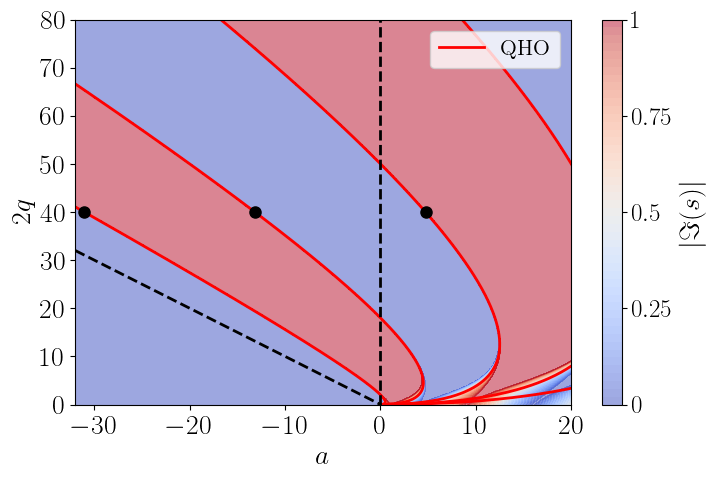

In [20]:
from scipy.ndimage import gaussian_filter

qtest = 20
pent = 6

with open('Map_rho_HQO.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aashape = aanum
qqshape = qqnum
aashape.shape=(1,mat_row)
qqshape.shape=(1,mat_col)

Mq = np.dot(np.transpose(aashape),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqshape)



# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.00001,1+0.00001,50)

fig1 = plt.figure(1, figsize=(8, 5))
plt.rc('text', usetex=True)

#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|\Im(s)|$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed



# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)

qqnum = np.linspace(0, 40, 500)
plt.plot((0.5+0)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2,label=r'$\mathrm{QHO}$')
plt.plot((0.5+1)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+2)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+3)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)
plt.plot((0.5+4)*4*np.sqrt(qqnum)-2*qqnum,2*qqnum,'r',linewidth=2)

plt.plot(aanum, -aanum*pent, 'g-',linewidth=3) 
plt.plot([0.,0.],[0.,100.], 'k--',linewidth=2) 
plt.plot([-32.,0.],[32.,0.], 'k--',linewidth=2) 
#plt.plot([0.,30.],[0.,30.], 'k--',linewidth=2)

plt.plot(-2*qtest+energiesana,np.ones(energiesana.size)*qtest*2, 'k.',markersize=16)
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q$', fontsize=fonty)  # y-axis: q
plt.xlim(-32, 20.)
plt.ylim(0.,80.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty-4, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

fig1.savefig('HQO_stability_chart_aq_negative.png', format='png', dpi=1000, bbox_inches='tight')

### → Figure 4d — QHO bound states comparison

Overlays the Transmon eigenstates (exact) with the QHO/Hermite approximation
and the classical Bloch wave envelopes for a final side-by-side comparison.
Produces `QHO_bound_states_comparison.png`.


[-31.31339741 -14.49111706   1.16052624  15.49304153  28.46304799]


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_73416/1312735153.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))


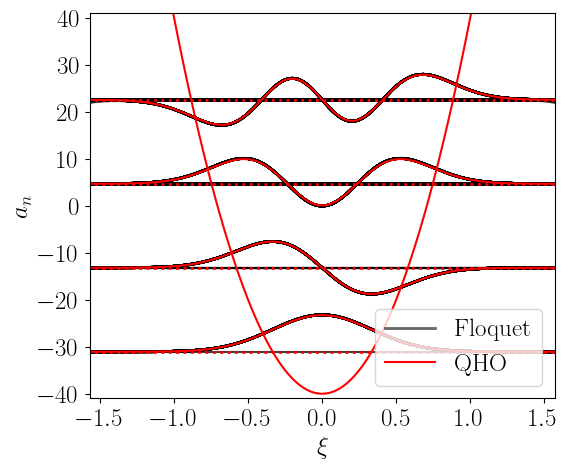

In [21]:
qtest = 20
phi_max = np.pi  # Range for φ
num_points = 2000
phi = np.linspace(-phi_max, phi_max, num_points)

#Laplacy = calculate_laplace_three_point(phi)
#Potent = diags(qtest*phi**2)
#energies, states = eigs((-Laplacy+Potent),k=4, which='SR')

E_C = 1.0  # Charging energy
E_J = 2*qtest*E_C  # Josephson energy
dphi = phi[1] - phi[0]

# Potential term: V(phi) = -E_J * cos(phi)
V = -E_J * np.cos(phi)

# Kinetic term: T = -4 * E_C * d^2/dphi^2
kinetic = -4 * E_C / dphi**2
diagonal_kinetic = np.full(num_points, -2 * kinetic)
off_diagonal_kinetic = np.full(num_points - 1, kinetic)
T = diags([diagonal_kinetic, off_diagonal_kinetic, off_diagonal_kinetic], [0, -1, 1])

# Full Hamiltonian: H = T + V
H = T + diags([V], [0])

# Solve for eigenvalues and eigenvectors
eigenval, eigenvec = eigh(H.toarray())
eigenval = eigenval[:5]  # Only take the first 10 eigenvalues
eigenvec = eigenvec[:, :5]
print(eigenval)

nlist = np.linspace(0,3,4)
energiesana = (0.5+nlist)*4*np.sqrt(qtest)
eigenvectors = np.zeros((nlist.size,phi.size))

chi = np.sqrt(2)*(qtest)**0.25*(phi/2)
inc = -1
for nn in nlist:
    inc = inc + 1
    p_monic = sp.hermite(nn.astype(int), monic=True)
    eigenvectors[inc,:] = p_monic(chi)*np.exp(-np.sqrt(qtest)*(phi/2)**2)*((2*np.sqrt(qtest)/np.pi)**(0.25))/(cm.sqrt(2**nn*sp.factorial(int(nn))))

Amp0 = 6
Amp1 = 10
Amp2 = 20
Amp3 = 42

fonty = 18
fig7 = plt.figure(7, figsize=(6, 5))
plt.rc('text', usetex=True)

#plt.plot(phi/2, eigenvec[:, 0]*148 + eigenval[0]+0.25,'g-')
#plt.plot(phi/2, eigenvec[:, 1]*104 + eigenval[1]+1.25,'g-')

for y_value in listA[indices]:
    plt.axhline(y=y_value, color='k', linestyle='-', alpha=0.5)
for ii in range(20):
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0013*np.real(MAtFloq0A[ii,:])/np.real(coeff0A*rho0A**ii) + energiesana[0]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0013*np.real(MAtFloq0B[ii,:])/np.real(coeff0B*rho0B**ii) + energiesana[0]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0072*np.real(MAtFloq1A[ii,:])/np.real(coeff1A*rho1A**ii) + energiesana[1]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.0072*np.real(MAtFloq1B[ii,:])/np.real(coeff1B*rho1B**ii) + energiesana[1]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.034*np.real(MAtFloq2A[ii,:])/np.real(coeff2A*rho2A**ii) + energiesana[2]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,0.034*np.real(MAtFloq2B[ii,:])/np.real(coeff2B*rho2B**ii) + energiesana[2]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,-0.13*np.real(MAtFloq3A[ii,:])/np.real(coeff3A*rho3A**ii) + energiesana[3]-2*qtest,'k',linewidth=2,alpha=0.6)
    plt.plot(listcell[0:-1:1]-np.pi/2.,-0.13*np.real(MAtFloq3B[ii,:])/np.real(coeff3B*rho3B**ii) + energiesana[3]-2*qtest,'k',linewidth=2,alpha=0.6)
        
plt.plot(np.NaN,np.NaN,'k',linewidth=2,alpha=0.6,label=r'$\mathrm{Floquet}$')

#plt.plot(xxquantum, energiesana[0]+Amp*states[:, 0].real, label='$\psi_0$')
plt.plot(phi/2, -2*qtest+energiesana[0]+Amp0*eigenvectors[0,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[1]-Amp1*eigenvectors[1,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[2]+Amp2*eigenvectors[2,:].real,'r-')
plt.plot(phi/2, -2*qtest+energiesana[3]+Amp3*eigenvectors[3,:].real,'r-')

plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[0]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[1]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[2]),'r:',linewidth=2)
plt.plot(np.array([phi[0],phi[-1]]), np.array([1.,1.])*(-2*qtest+energiesana[3]),'r:',linewidth=2)

plt.plot(phi/2, 4*qtest*(phi/2)**2-2*qtest,'r-',markersize=3.,label=r'$\mathrm{QHO}$')
#plt.plot(phi/2, -2*qtest * np.cos(phi),'g-',linewidth=2)

plt.xlabel(r'$\xi$', fontsize=fonty)
plt.ylabel('$a_n$', fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
legend = plt.legend(fontsize=fonty,loc='lower right')
plt.xlim(-phi_max/2, phi_max/2)
#plt.ylim(-1-2*qtest, 4*qtest*(np.pi/2)**2-2*qtest)
plt.ylim(-1-2*qtest, 40+1)
fig7 = plt.gcf()
plt.show()

fig7.savefig('QHO_bound_states_comparison.png', format='png', dpi=1000,bbox_inches='tight')


## By Arnaud Lazarus - 06/13/2026